# The theory behind the flow-field plots

*What dynamical system the "arrow" plots show, the math behind them, and why we use
them.* Based on the collective-reinforcement-learning-dynamics (CRLD) framework of
Barfuss and colleagues — see references at the end.

---

## 1. What is actually "moving"?

The arrows do **not** show agents moving in a game. They show how the agents'
**strategies change as they learn**. The object that evolves is the **joint
strategy** $X$: the probability each agent $i$ assigns to each action $a$ in each
state $s$,
$$X_i(a\mid s) \;=\; \Pr(\text{agent }i\text{ plays }a\text{ when it observes }s).$$

In the **memory-1 Iterated Prisoner's Dilemma** each agent conditions on last
round's outcome, so the states are $s\in\{cc,\,cd,\,dc,\,dd\}$. Each agent then has
4 cooperation probabilities, and the **joint strategy is an 8-dimensional vector**.

> **A single point in a flow plot = one complete joint strategy.** Our plots show a
> 2-D *slice* of that 8-D space: agent-0's $P(\text{cooperate})$ on the x-axis vs
> agent-1's on the y-axis, in one chosen state (we use the "both cooperated last
> round" state). The corners are the pure outcomes: $(0,0)$ = mutual defection,
> $(1,1)$ = mutual cooperation.

## 2. The dynamics: a deterministic learning map in strategy space

Each learning step nudges the policy in the direction of the **temporal-difference
(reward-prediction) error** $\delta$, through a softmax / replicator–mutator update:

$$
X^{t+1}_i(a\mid s)\;=\;
\frac{X^{t}_i(a\mid s)\,\exp\!\big(\alpha\,\beta\,\delta^{t}_i(s,a)\big)}
     {\sum_{b} X^{t}_i(b\mid s)\,\exp\!\big(\alpha\,\beta\,\delta^{t}_i(s,b)\big)} .
$$

- $\alpha$ — **learning rate** (step size).
- $\beta$ — **intensity of choice** / inverse temperature (exploit vs. explore).
- $\delta^{t}_i(s,a)$ — the **TD error**: how much better than expected action $a$
  in state $s$ turned out to be.

The TD error itself is

$$
\delta_i(s,a)\;=\;
\underbrace{(1-\gamma)\,\bar R_i(s,a)}_{\text{immediate reward}}
\;+\;
\underbrace{\gamma\,\overline{V}^{\,\text{next}}_i(s,a)}_{\text{discounted future}}
\;-\;
\underbrace{\tfrac{1}{\beta}\ln X_i(a\mid s)}_{\text{current estimate / baseline}},
$$

with $\gamma\in[0,1)$ the **discount factor** (how much they care about the future).
The $(1-\gamma)$ prefactor just puts immediate and future returns on the same scale.

The **strategy-averaged** reward replaces sampled experience with the *exact
expectation* under the current joint policy:

$$
\bar R_i(s,a)\;=\;\sum_{s'}\sum_{a_{-i}}
X_{-i}(s,a_{-i})\;T(s,a,a_{-i},s')\;R_i(s,a,a_{-i},s'),
$$

(summing over the other agents' actions $a_{-i}$ weighted by their policy, the
transition $T$, and the reward $R$). The successor value $\overline{V}^{\text{next}}$
is defined analogously and obtained in closed form from the Bellman equation.

> The key word is **strategy-averaged**. Because we plug in the *exact expectation*
> rather than noisy samples, the update is **deterministic** — at every strategy
> $X$ there is a single, well-defined next strategy, hence a single arrow.

## 3. What the flow field *is*

Define the one-step change

$$\Delta X \;=\; X^{t+1}-X^{t}.$$

At every point $X$ in strategy space this is a vector. The field of all these
vectors is the **flow** (the "wind"); plotting it on a grid is exactly what
`pyCRLD`'s `fp.plot_strategy_flow` does. So:

- **Each coloured arrow** = the direction (and, by colour, the strength) the
  learning rule pushes the joint policy *from that point*.
- **A purple line** = one *trajectory*: start from some strategy and follow the
  arrows. It is one run of the learning dynamics, $X^0 \to X^1 \to \dots$
- **A fixed point** ($\Delta X = 0$, where the arrows vanish) = a strategy the
  dynamics converge to — a **learned equilibrium**. The marker `x` is the start,
  `o` the converged fixed point.

This is the bridge Barfuss draws between **reinforcement learning** and
**evolutionary game theory**: the update above is a *replicator–mutator* equation,
with $\alpha\beta\,\bar q$ playing the role of "fitness".

## 4. Reading one — a live example

The cell below builds the deterministic dynamics for a single social dilemma and
draws its flow field with one trajectory overlaid.

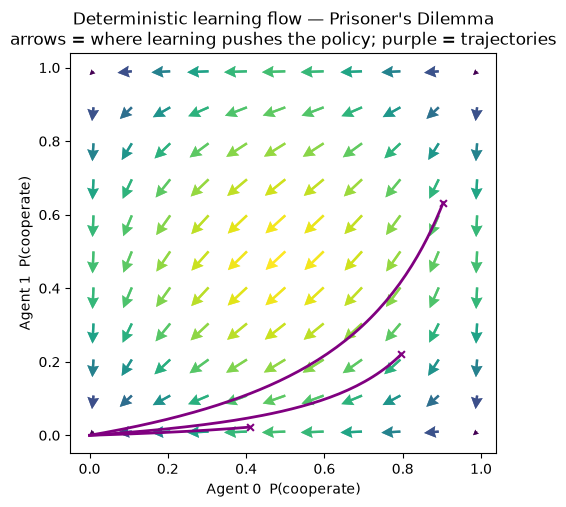

In [1]:
import os, sys
os.environ.setdefault("JAX_PLATFORMS", "cpu")       # tiny analytic compute, no GPU
sys.path.insert(0, os.path.dirname(os.getcwd()))    # repo root for pyCRLD
import numpy as np
import matplotlib.pyplot as plt
from pyCRLD.Agents.StrategyActorCritic import stratAC
from pyCRLD.Environments.SocialDilemma import SocialDilemma
from pyCRLD.Utils import FlowPlot as fp

env = SocialDilemma(R=1.0, T=1.5, S=-0.5, P=0.0)        # a Prisoner's Dilemma
mae = stratAC(env=env, learning_rates=0.1, discount_factors=0.9)
x = ([0], [0], [0]); y = ([1], [0], [0])               # agent-0 vs agent-1 P(cooperate)

fig, ax = plt.subplots(figsize=(5.5, 5.2))
fp.plot_strategy_flow(mae, x, y, use_RPEarrows=False,
                      flowarrow_points=np.linspace(0.01, 0.99, 11), axes=[ax])
for seed in range(3):
    np.random.seed(seed)
    xt, _ = mae.trajectory(mae.random_softmax_strategy(), Tmax=8000, tolerance=1e-5)
    fp.plot_trajectories([xt], x, y, cols=["purple"], axes=ax)
ax.set_xlabel("Agent 0  P(cooperate)"); ax.set_ylabel("Agent 1  P(cooperate)")
ax.set_title("Deterministic learning flow — Prisoner's Dilemma\n"
             "arrows = where learning pushes the policy; purple = trajectories")
plt.show()

Every arrow points toward the lower-left: from anywhere, the deterministic
learning dynamics drive both agents to **mutual defection $(0,0)$**. That single
picture tells you the *entire* basin structure of the game under this learner —
which is the whole point (next section).

## 5. Why we use these plots

A learning **curve** (reward vs. time) shows you *one* run from *one* start. A
**flow field** shows the rule everywhere at once, so you can read off things a curve
can't:

1. **Attractors** — where does learning end up? (the fixed points / corners).
2. **Basins of attraction** — *which* starting strategies lead to cooperation vs.
   defection, and how big each basin is. (e.g. Stag Hunt is **bistable**: two
   basins split by a separatrix.)
3. **Separatrices** — the ridge line dividing basins; it tells you how *robust*
   cooperation is to perturbation.
4. **Comparisons at a glance** — because the field is the analytic rule, we can lay
   the *same* picture side by side across **games**, **algorithms** (actor-critic
   vs. SARSA), **observability regimes**, and **player counts**, and see exactly
   which lever moves the attractor. (That is what the `flow_grids_notebook` does.)

The cost is that it requires the **analytic** dynamics object (the strategy-averaged
$\delta$), so it exists only for the small, tractable CRLD social dilemmas — not for
the sampled deep-RL runs, which only give trajectories.

## 6. The catch — and "intrinsic fluctuations"

The deterministic flow is the **infinite-batch limit**: it averages over
*infinitely many* interactions before each update, so it shows the *mean* learning
direction. Real reinforcement learning uses a **finite batch of $K$ samples**, so
each update is a **noisy** estimate of $\delta$. The actual trajectory is

$$X^{t+1} \;=\; \underbrace{\text{deterministic flow}}_{\text{the arrows}} \;+\;
\underbrace{\text{sampling noise}}_{\;\sim\, 1/\sqrt{K}\;,\ \text{vanishes as }K\to\infty}.$$

This noise is **intrinsic** — it is produced by the learning process's own finite
sampling, not added by hand. Barfuss & Meylahn (2023) show why it matters: the
deterministic IPD flow drains into the **defection** fixed point (large basin), but
the noise can **kick the trajectory across the separatrix** into the **cooperation**
basin (win-stay–lose-shift / tit-for-tat is also a stable fixed point). Because the
cooperative fixed point is "stickier" once reached, the system spends more time
there — and intrinsic fluctuations **roughly double the cooperation rate (up to
~80%)**, on top of a high discount $\gamma$, low exploration, and small $\alpha$.

> **So how to read our defection-bound flow plots:** they show the *deterministic
> skeleton* of the dynamics (the average pull, often toward defection). The
> fluctuations a real learner experiences ride on top of that skeleton and can lift
> cooperation well above what the bare flow predicts. This is also why our
> finite-batch deep-RL value learner (IQL) cooperated (~0.95) while the
> deterministic actor-critic flow defects — fluctuations + value bootstrapping,
> exactly as the paper describes.

# Empirical findings from the flow grids (candidate paper results)

Reading the 16 observability flow grids (`flow_grids_notebook.ipynb`), here are the
patterns — your observations, my verdict on each, and a few additional results that
look paper-worthy. Grids are embedded under each point.

In [2]:
import glob
def show(fname, title, figsize=(13, 8)):
    p = os.path.join(os.getcwd(), "results", fname)
    if not os.path.exists(p):
        print("(missing:", fname, ")"); return
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=figsize); ax.imshow(mpimg.imread(p)); ax.axis("off")
    ax.set_title(title, fontsize=11, loc="left", color="#114"); plt.show()

## F1. Self-awareness beats opponent-awareness  ✅ (agree)

> *Your observation:* in the IPD, being **self-aware** (seeing your own last action)
> is more beneficial than being **non-self-aware** (seeing only the opponent's).

I agree, and there's a crisp mechanism: the cooperative memory-1 strategies that
matter — **win-stay–lose-shift** and tit-for-tat — are conditioned on *your own*
last move. You literally cannot "stay" or "shift" if you don't know what you did.
Seeing only the opponent is not enough to *execute* reciprocity. So self-awareness
is the load-bearing observation; opponent-awareness alone leaves the agent unable
to close the reciprocity loop. The same pattern holds in **coin_game** (slightly
improved by self-awareness, slightly hurt by non-self-awareness).

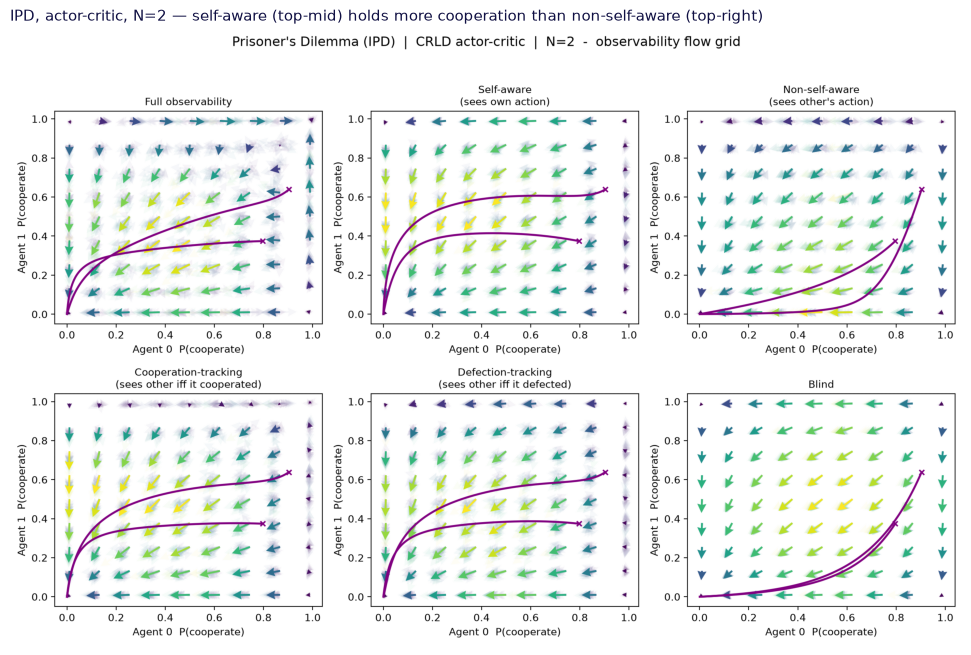

In [3]:
show("obsgrid_ipd_ac_N2.png", "IPD, actor-critic, N=2 — self-aware (top-mid) holds more cooperation than non-self-aware (top-right)")

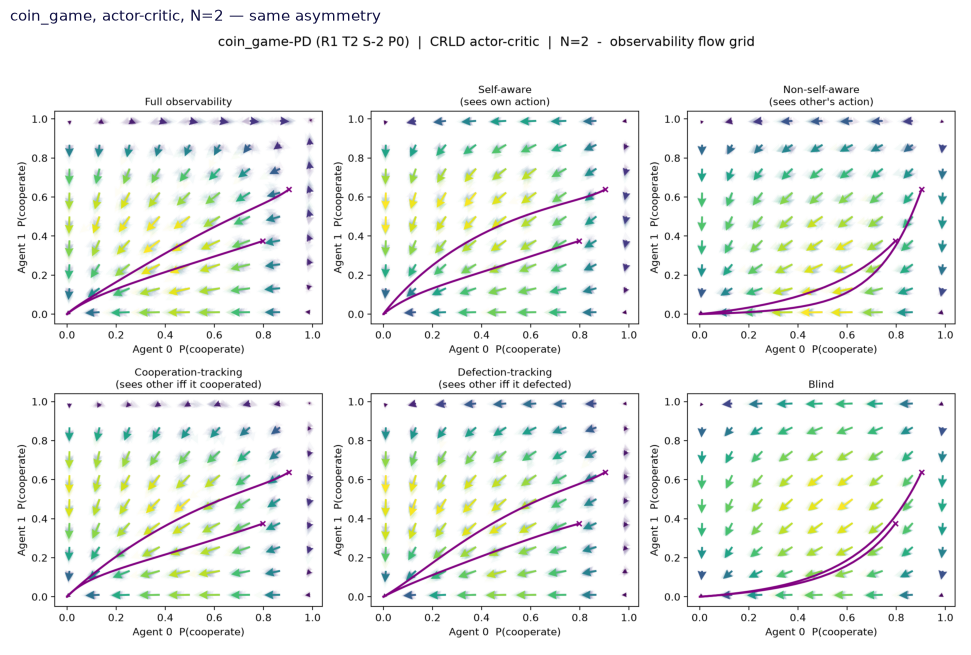

In [4]:
show("obsgrid_coin_ac_N2.png", "coin_game, actor-critic, N=2 — same asymmetry")

## F2. Stag Hunt amplifies the self / non-self gap  ✅ (agree, with one nuance)

> *Your observation:* in Stag Hunt the self/non-self effect is even stronger — no
> self-awareness goes to defection, self-awareness to cooperation.

Agreed and it's the strongest single demonstration of F1. Because Stag Hunt is
**bistable** (two basins — cooperate or defect — split by a separatrix), the
observability change doesn't just shade the outcome, it **decides which basin you
fall into**: self-aware trajectories climb to **(1,1)**, non-self-aware ones never
reach it. *Nuance for the paper:* non-self-aware here lands on a **low / asymmetric**
state (one agent ~0.4), not pure (0,0) defection — so "fails to coordinate on the
cooperative equilibrium" is more precise than "goes to defection".

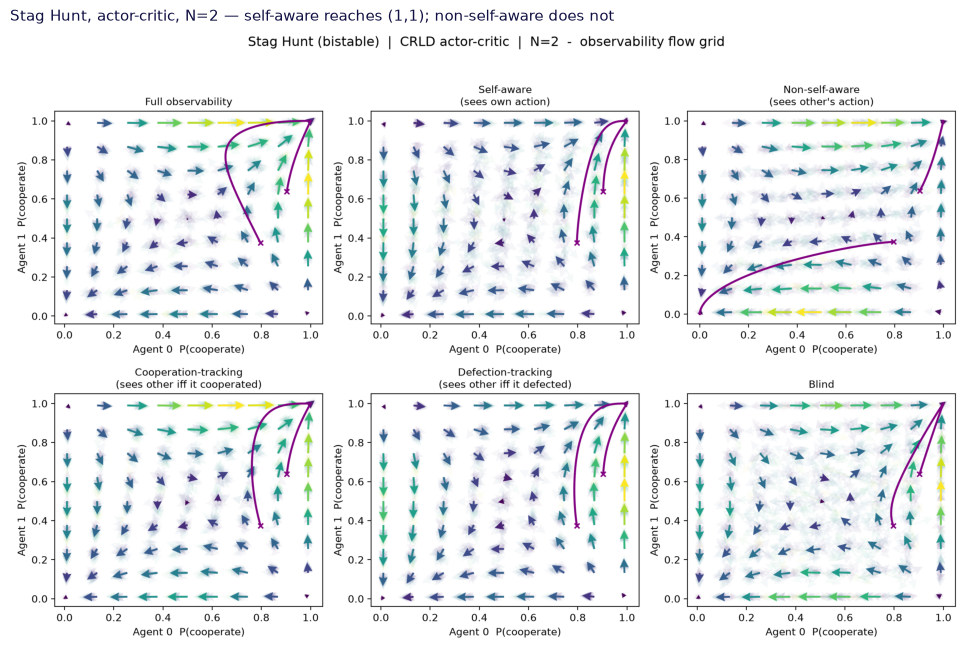

In [5]:
show("obsgrid_staghunt_ac_N2.png", "Stag Hunt, actor-critic, N=2 — self-aware reaches (1,1); non-self-aware does not")

## F3. Conditional (coop/def-tracking) observation barely matters  ✅ (agree)

> *Your observation:* tracking the opponent only when it cooperates / only when it
> defects doesn't change the outcomes for IPD / Harmony / Chicken / Stag Hunt.

Agreed — the cooperation-tracking and defection-tracking panels look essentially
like full observability in every game. Interpretation: once the agent keeps its
**own** action (which all three of full / coop-track / def-track do), it already has
what reciprocity needs; *filtering which of the opponent's moves it also sees* is a
second-order effect. The first-order lever is self- vs non-self-awareness (F1), not
the conditional content.

## F4. Snowdrift/Chicken: the **algorithm selects the equilibrium**  ⭐ (new result)

> *Your observation:* in Snowdrift the actor-critic results look "weird"; in SARSA
> they are "completely clean — what's going on?"

This is the most interesting thing in the whole matrix. Snowdrift/Chicken has
**three** equilibria: two *pure anti-coordination* outcomes $(C,D)$ and $(D,C)$, and
one *symmetric mixed* interior point near $(0.5,0.5)$. **The two learning rules pick
different ones:**

- **Actor-critic (policy gradient)** flows to the **pure anti-coordination corners**
  (off-diagonal) — like the two-population replicator dynamics, where the interior
  mixed point is a saddle. That's why it looks "weird/asymmetric": the symmetric
  start is repelled toward an asymmetric C-vs-D split.
- **SARSA (value-based)** converges **cleanly to the symmetric mixed interior point**
  $(0.5,0.5)$ from everywhere — and, crucially, in **all six observability regimes
  identically**. That's why it's "completely clean".

So Chicken is a case of **algorithm-dependent equilibrium selection**: the same game
yields *asymmetric specialisation* under policy gradient but a *symmetric mixed*
convention under value-based learning. That's a clean, citable result.

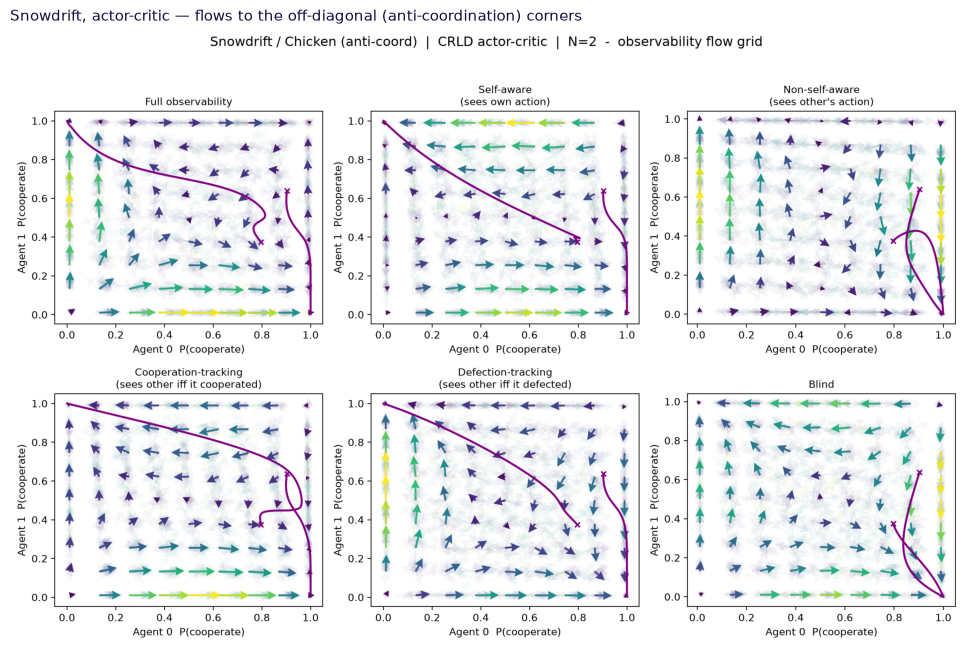

In [6]:
show("obsgrid_snowdrift_ac_N2.png", "Snowdrift, actor-critic — flows to the off-diagonal (anti-coordination) corners")

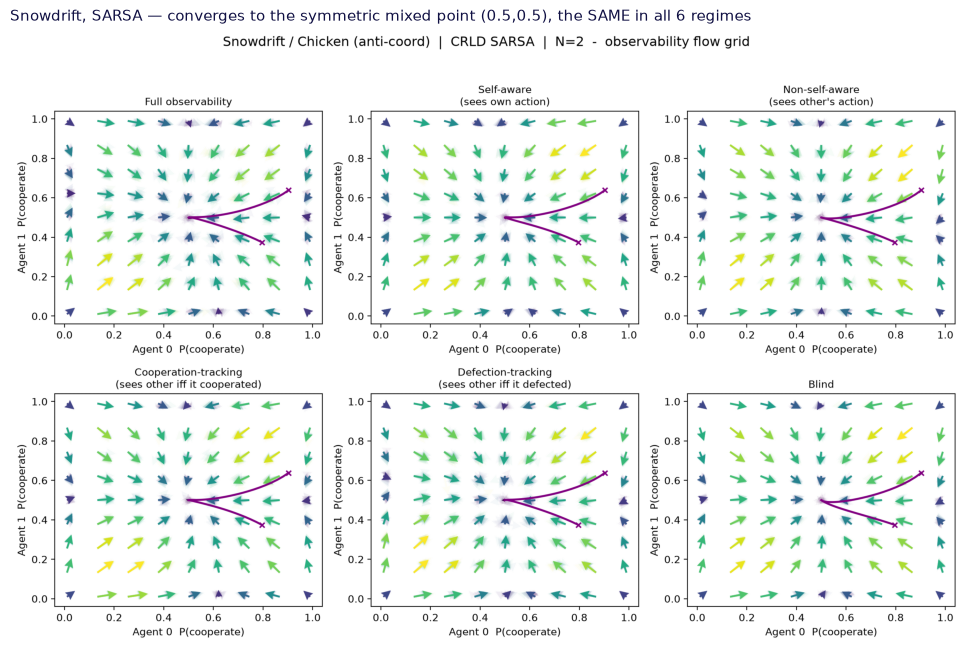

In [7]:
show("obsgrid_snowdrift_sarsa_N2.png", "Snowdrift, SARSA — converges to the symmetric mixed point (0.5,0.5), the SAME in all 6 regimes")

## F5. Can we extract clean sentences from SARSA? Mostly **no** — except Snowdrift

> *Your question:* for SARSA everything turns much more chaotic — can clean
> sentences still be extracted, or not?

Honest answer: **not the way you can for actor-critic.** SARSA's attractors in the
reciprocity games (PD, Stag Hunt) are *interior partial-cooperation* fixed points
that **shift with the observability regime**, and the background flow is a 2-D
average that renders noisily — so the per-regime story is muddy. The one robust
SARSA statement across games is the qualitative one: **value-based learning sustains
more cooperation than policy gradient** (e.g. IPD: SARSA ~0.4 vs actor-critic ~0).

**Snowdrift is the exception (and explains F4's "clean"):** its interior attractor
is set by the payoff *anti-symmetry*, not by reciprocity, so it is **invariant to
the observation regime** — all six panels collapse to the same clean picture. In the
reciprocity games there is no such regime-invariant attractor, hence the mess.

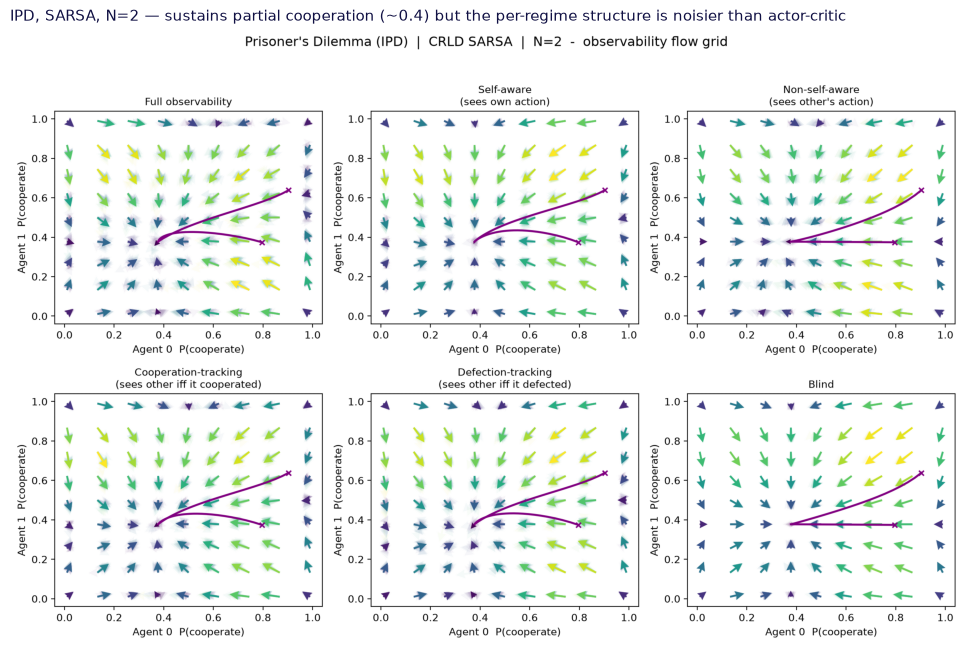

In [8]:
show("obsgrid_ipd_sarsa_N2.png", "IPD, SARSA, N=2 — sustains partial cooperation (~0.4) but the per-regime structure is noisier than actor-critic")

## F6. Players: cooperation can *rise* with N — but the 2-D picture degrades  ✅/⚠️

> *Your observations (arena):* with 3 players we see even more cooperation; with 4
> players it becomes really confusing; and SARSA at N=4 is an empty graph.

Two separate things are going on:
1. **Real effect:** in the pairwise-averaged N-player dilemma, cooperation **rises**
   with N (a defection spoils only 1 of N−1 pairwise terms, shrinking the temptation
   gradient). So N=3 genuinely shows more cooperation than N=2 — that is a result.
2. **Artifact:** for N>2 the plot is a **2-D projection** of a $2^N$-state,
   high-dimensional strategy space (averaging over the hidden agents). At **N=4** the
   actor-critic field is heavily scattered and trajectories zig-zag (nearby-in-2-D
   points are far apart in the true space), and **SARSA N=4 fails numerically** —
   the projected flow returns NaN, so the panel is empty (just the start markers).

**Recommendation for the paper:** present the N-player (arena) result at **N=2 and
N=3 only**; flag N=4 as the point where the 2-D projection breaks down rather than a
finding.

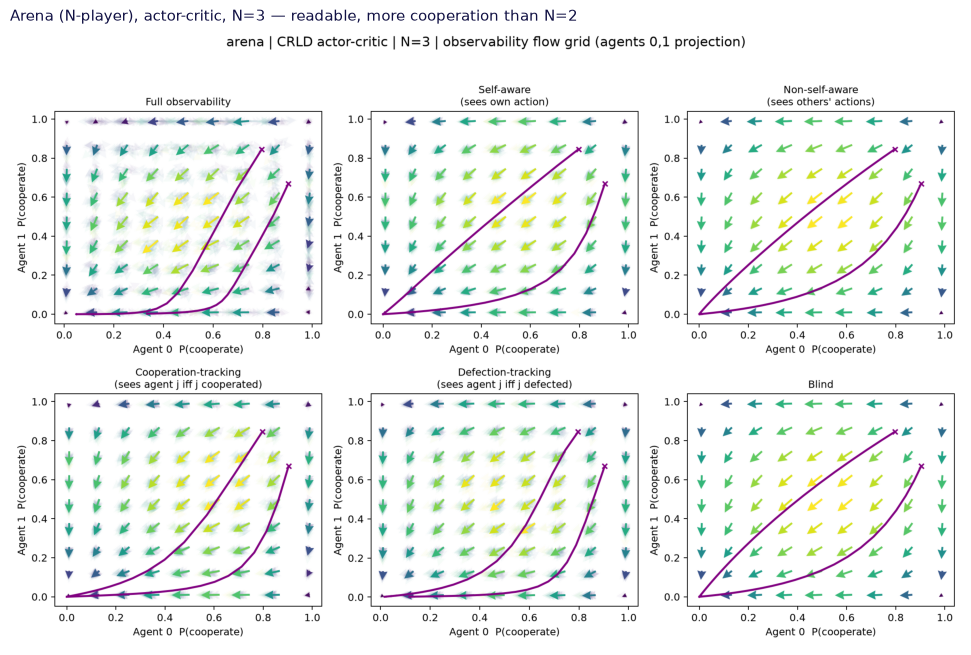

In [9]:
show("obsgrid_arena_ac_N3.png", "Arena (N-player), actor-critic, N=3 — readable, more cooperation than N=2")

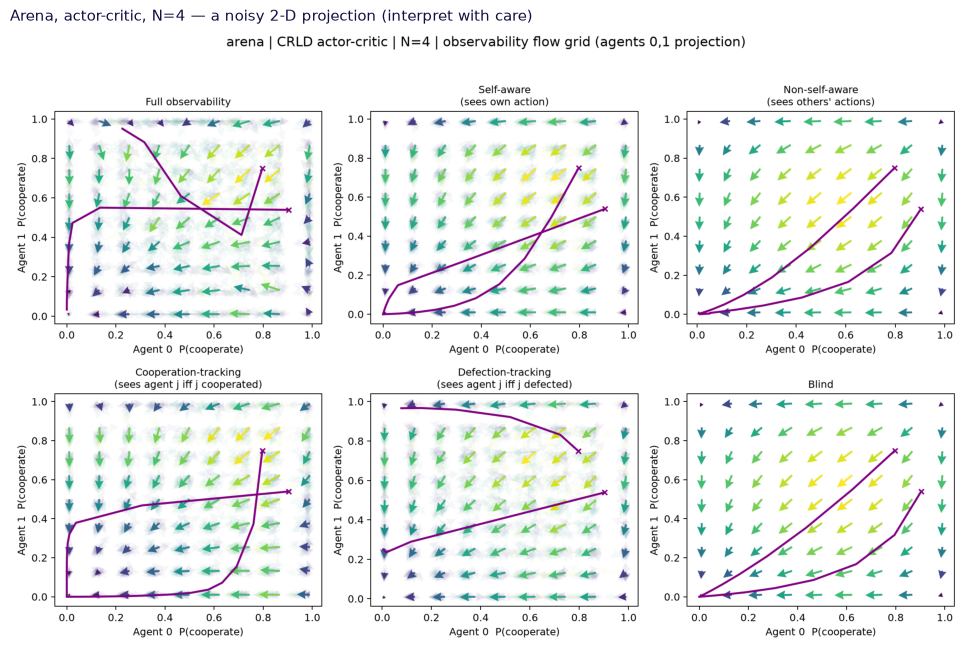

In [10]:
show("obsgrid_arena_ac_N4.png", "Arena, actor-critic, N=4 — a noisy 2-D projection (interpret with care)")

## F7. Clarification — the arena's "IPPO/A2C" label

> *Your question:* for the arena, why "IPPO/A2C" — shouldn't it be one or the other?
> Did we only try actor-critic?

**IPPO and A2C are the same algorithm family** — both are policy-gradient
actor-critic methods (IPPO just adds PPO clipping). The single **CRLD actor-critic**
flow is the *deterministic limit of both*, which is why the label reads "~ IPPO/A2C":
it means "this one analytic dynamics stands in for both", **not** "we ran two
algorithms". For the *deep-RL* arena (the STORM gridworld in `results_notebook`), the
N-agent and observability experiments used **IPPO** specifically; a separate
algorithm comparison there ran IPPO vs A2C vs IQL.

## Summary of observations (your words → my verdict)

| # | observation | verdict |
|---|---|---|
| F1 | IPD: self-aware > non-self-aware | ✅ agree (reciprocity needs your *own* action) |
| F2 | Stag Hunt amplifies the self/non-self gap | ✅ agree (bistable → observability picks the basin); non-self → asymmetric, not pure (0,0) |
| F3 | coop/def-tracking doesn't change outcomes | ✅ agree (own-action channel carries reciprocity) |
| F4 | Snowdrift AC weird / SARSA clean | ⭐ **algorithm-dependent equilibrium selection** — AC → pure anti-coord corners, SARSA → symmetric mixed point |
| F5 | SARSA is chaotic, hard to read | ✅ agree — only robust claim is "SARSA cooperates more"; clean only for Snowdrift |
| F6 | more players → more cooperation; N=4 confusing; SARSA N=4 empty | ✅ rise-with-N is real; ⚠️ N=4 is a projection artifact (SARSA N=4 = NaN) |
| coin | same pattern as IPD; SARSA coin more coop but still toward defection | ✅ agree |

---

## References

- W. Barfuss, J. M. Meylahn. **Intrinsic fluctuations of reinforcement learning
  promote cooperation.** *Scientific Reports* 13, 1309 (2023).
  [open access (PMC)](https://pmc.ncbi.nlm.nih.gov/articles/PMC9873645/)
- W. Barfuss. **Dynamical systems as a level of cognitive analysis of multi-agent
  learning.** *Neural Computing and Applications* 34, 1653–1671 (2022).
  [open access (PMC)](https://pmc.ncbi.nlm.nih.gov/articles/PMC8827307/)
- W. Barfuss, J. F. Donges, J. Kurths. **Deterministic limit of temporal difference
  reinforcement learning for stochastic games.** *Physical Review E* 99, 043305 (2019).
- W. Barfuss. **pyCRLD** — Collective Reinforcement Learning Dynamics in Python.
  <https://wbarfuss.github.io/pyCRLD/>